## SECTION 0 — Setup & Imports

In [1]:
!pip install timm -q

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch  : {torch.__version__}")
print(f"Pandas   : {pd.__version__}")
print(f"Numpy    : {np.__version__}")
print(f"Timm     : {timm.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device   : {device}")

torch.manual_seed(42)
np.random.seed(42)
os.makedirs("results/plots", exist_ok=True)
os.makedirs("data/satellite_npy", exist_ok=True)

PyTorch  : 2.10.0
Pandas   : 3.0.1
Numpy    : 2.4.3
Timm     : 1.0.25
Device   : mps


/Users/qasimnalawala/Desktop/Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## SECTION 1 — Data Loading & EDA

Shape : (7640, 16)

Null counts:
 timestamp                   0
temperature_2m              0
relative_humidity_2m        0
rain                        0
wind_speed_10m              0
cloud_cover                 0
ghi                         0
direct_normal_irradiance    0
diffuse_radiation           0
ghi_clearsky                0
pv_actual                   0
sg_timestamp_naive          0
utc_timestamp               0
image_path                  5
time_diff_minutes           5
clearsky_ratio              0
dtype: int64


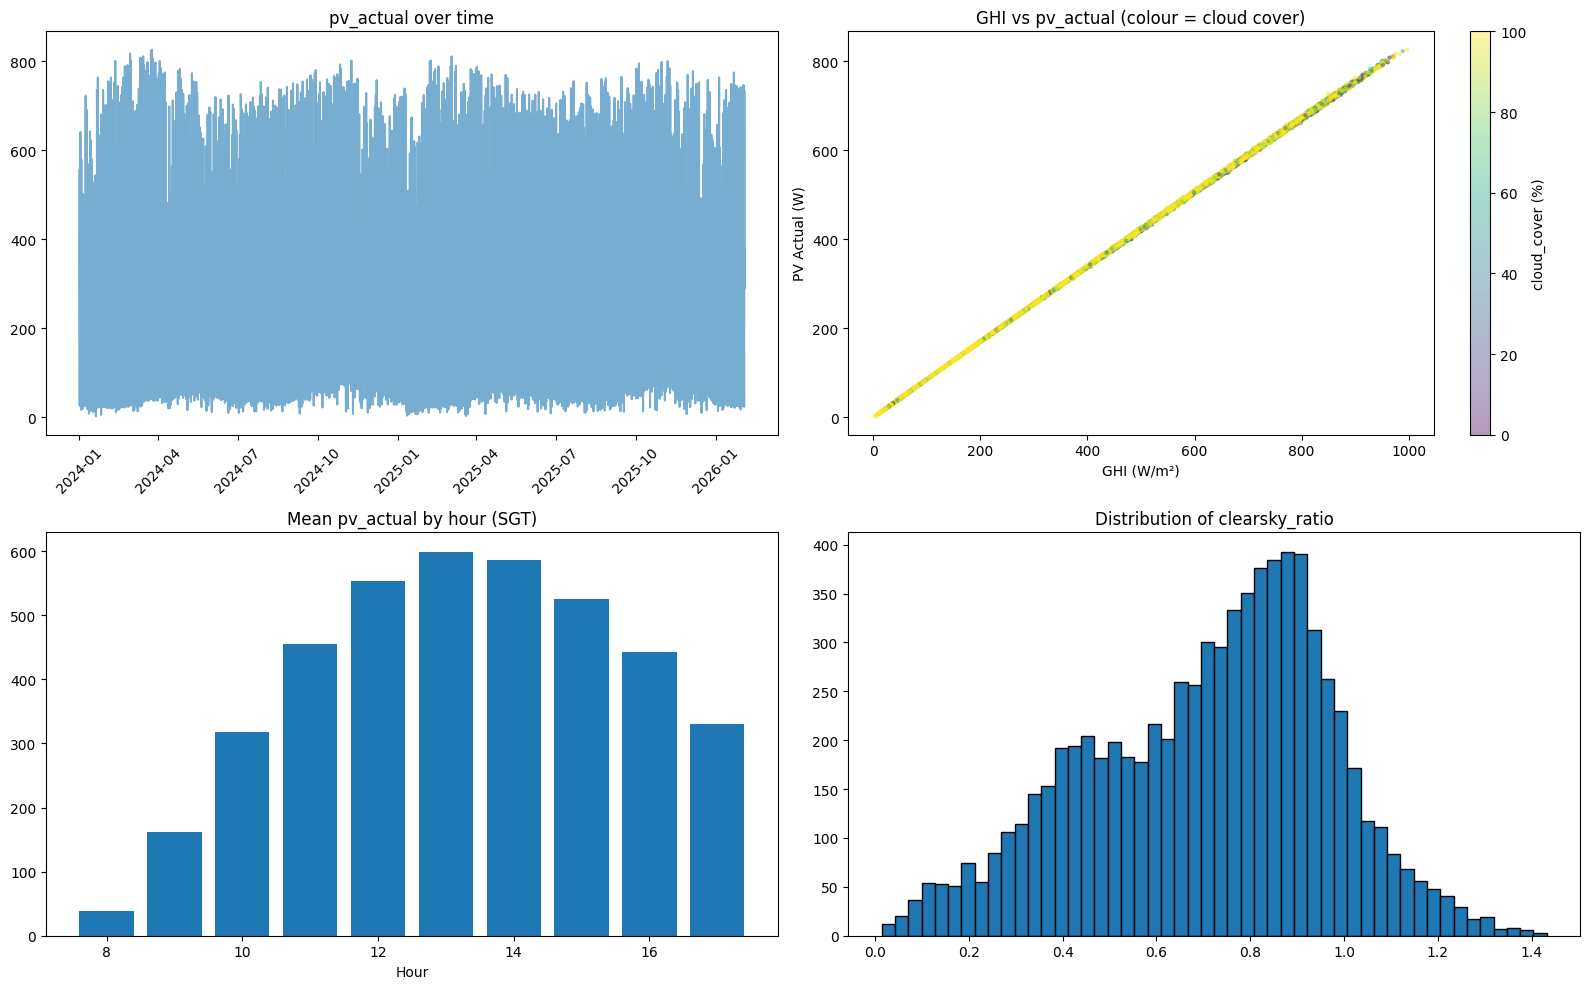


Correlation with pv_actual:
pv_actual                   1.000000
ghi                         0.999941
temperature_2m              0.861473
direct_normal_irradiance    0.818184
ghi_clearsky                0.810031
clearsky_ratio              0.766401
diffuse_radiation           0.529029
wind_speed_10m              0.333760
time_diff_minutes          -0.001575
rain                       -0.052251
cloud_cover                -0.193514
relative_humidity_2m       -0.811313
Name: pv_actual, dtype: float64


In [2]:
df = pd.read_csv("data/combined_dataset.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

if "clearsky_ratio" not in df.columns:
    df["clearsky_ratio"] = df["ghi"] / (df["ghi_clearsky"] + 1e-6)

print("Shape :", df.shape)
print("\nNull counts:\n", df.isnull().sum())

fig, axs = plt.subplots(2, 2, figsize=(16, 10))

axs[0,0].plot(df["timestamp"], df["pv_actual"], alpha=0.6)
axs[0,0].set_title("pv_actual over time")
axs[0,0].tick_params(axis="x", rotation=45)

sc = axs[0,1].scatter(df["ghi"], df["pv_actual"],
                       c=df["cloud_cover"], cmap="viridis", alpha=0.4, s=5)
plt.colorbar(sc, ax=axs[0,1], label="cloud_cover (%)")
axs[0,1].set_title("GHI vs pv_actual (colour = cloud cover)")
axs[0,1].set_xlabel("GHI (W/m²)"); axs[0,1].set_ylabel("PV Actual (W)")

hourly = df.groupby(df["timestamp"].dt.hour)["pv_actual"].mean()
axs[1,0].bar(hourly.index, hourly.values)
axs[1,0].set_title("Mean pv_actual by hour (SGT)")
axs[1,0].set_xlabel("Hour")

axs[1,1].hist(df["clearsky_ratio"].clip(0, 1.5), bins=50, edgecolor="black")
axs[1,1].set_title("Distribution of clearsky_ratio")

plt.tight_layout(); plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns
print("\nCorrelation with pv_actual:")
print(df[num_cols].corr()["pv_actual"].sort_values(ascending=False))

## SECTION 2 — Leakage Investigation

In [3]:
# 2a. Show the leakage
r = df["ghi"].corr(df["pv_actual"])
print(f"Pearson r(ghi, pv_actual) = {r:.6f}")
print("pv_actual was derived from ghi via a formula — r≈1 is expected but leaky.\n")

X_l = df[["ghi"]]; y_l = df["pv_actual"]
Xtr, Xte, ytr, yte = train_test_split(X_l, y_l, test_size=0.2, random_state=42)
lr_leak = LinearRegression().fit(Xtr, ytr)
print(f"Leaky LR (random split, ghi only) R² = {r2_score(yte, lr_leak.predict(Xte)):.4f}")
print("This is invalid — the model sees the future.\n")

# 2b. Honest baselines
df_b = df.copy()
for i in range(1, 7):
    df_b[f"pv_lag_{i}"]  = df_b["pv_actual"].shift(i)
    df_b[f"ghi_lag_{i}"] = df_b["ghi"].shift(i)
    df_b[f"cr_lag_{i}"]  = df_b["clearsky_ratio"].shift(i)
for i in range(1, 4):
    df_b[f"cc_lag_{i}"]  = df_b["cloud_cover"].shift(i)
df_b["temp_lag_1"]      = df_b["temperature_2m"].shift(1)
df_b["hour"]            = df_b["timestamp"].dt.hour
df_b["ghi_cs_t1"]       = df_b["ghi_clearsky"].shift(-1)
df_b["ghi_cs_t2"]       = df_b["ghi_clearsky"].shift(-2)
df_b["ghi_cs_t3"]       = df_b["ghi_clearsky"].shift(-3)
df_b["target_t1"]       = df_b["pv_actual"].shift(-1)
bdf = df_b.dropna().copy()

feats = ([f"pv_lag_{i}"  for i in range(1,7)] +
         [f"ghi_lag_{i}" for i in range(1,7)] +
         [f"cr_lag_{i}"  for i in range(1,7)] +
         [f"cc_lag_{i}"  for i in range(1,4)] +
         ["ghi_cs_t1","ghi_cs_t2","ghi_cs_t3","hour","temp_lag_1"])

nb = len(bdf)
btr, bval = int(nb*0.70), int(nb*0.85)
Xtr2 = bdf[feats].iloc[:btr];  ytr2 = bdf["target_t1"].iloc[:btr]
Xte2 = bdf[feats].iloc[bval:]; yte2 = bdf["target_t1"].iloc[bval:]

results = []
for mname, m in {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "LightGBM":          lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
}.items():
    m.fit(Xtr2, ytr2); p = m.predict(Xte2)
    results.append({"Model": mname,
                    "MAE":  mean_absolute_error(yte2, p),
                    "RMSE": np.sqrt(mean_squared_error(yte2, p)),
                    "R2":   r2_score(yte2, p)})

results_df = pd.DataFrame(results)
print("TRUE BASELINES (honest, time-based split):")
print(results_df.to_string(index=False))
print("\n→ These are the numbers the fusion model must beat.")

Pearson r(ghi, pv_actual) = 0.999941
pv_actual was derived from ghi via a formula — r≈1 is expected but leaky.

Leaky LR (random split, ghi only) R² = 0.9999
This is invalid — the model sees the future.

TRUE BASELINES (honest, time-based split):
            Model       MAE      RMSE       R2
Linear Regression 75.989437 97.249345 0.792039
    Random Forest 65.808799 89.028819 0.825711
         LightGBM 66.483742 89.803155 0.822666

→ These are the numbers the fusion model must beat.


## SECTION 3 — Image Preprocessing & Dataset

In [4]:
# ── Step 1: Save images as .npy files (run once, skips existing) ──────────────
# Avoids torchvision transform deadlock on Mac by using PIL + numpy only.

def save_images_as_npy(dataframe, npy_dir="data/satellite_npy"):
    paths = dataframe["image_path"].dropna().unique().tolist()
    total = len(paths)

    # Count already done
    already = sum(
        1 for p in paths
        if os.path.exists(
            os.path.join(npy_dir,
                         os.path.relpath(p, "data/satellite")).replace(".png", ".npy")
        )
    )
    if already == total:
        print(f"All {total} .npy files already exist — skipping.")
        return

    print(f"Saving {total - already} images as .npy (skipping {already} existing)...")
    start = time.time()

    for i, path in enumerate(paths):
        rel      = os.path.relpath(path, "data/satellite")
        npy_path = os.path.join(npy_dir, rel).replace(".png", ".npy")
        os.makedirs(os.path.dirname(npy_path), exist_ok=True)

        if os.path.exists(npy_path):
            continue

        try:
            with Image.open(path) as img:
                arr = np.array(
                    img.convert("RGB").resize((224, 224), Image.BILINEAR),
                    dtype=np.float32
                ) / 255.0
            np.save(npy_path, arr)
        except Exception as e:
            print(f"  Failed [{i}]: {path} — {e}")

        if (i + 1) % 500 == 0 or (i + 1) == total:
            elapsed   = time.time() - start
            done      = i + 1
            rate      = done / elapsed
            remaining = (total - done) / rate if rate > 0 else 0
            print(f"  {done}/{total} | {elapsed/60:.1f}m elapsed | "
                  f"~{remaining/60:.1f}m remaining | {rate:.0f} img/s")

    print("Done saving .npy files.")

save_images_as_npy(df)
print("\nImage preprocessing complete.")

All 7631 .npy files already exist — skipping.

Image preprocessing complete.


In [5]:
# ── Step 2: Dataset ────────────────────────────────────────────────────────────
NPY_DIR = "data/satellite_npy"
IMG_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMG_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

class SolarForecastDataset(Dataset):
    def __init__(self, dataframe, window_size=24, is_train=True, train_stats=None):
        self.df          = dataframe.copy().reset_index(drop=True)
        self.window_size = window_size

        if "clearsky_ratio" not in self.df.columns:
            self.df["clearsky_ratio"] = self.df["ghi"] / (self.df["ghi_clearsky"] + 1e-6)
        if "hour" not in self.df.columns:
            self.df["hour"] = pd.to_datetime(self.df["timestamp"]).dt.hour

        self.df["sin_hour"] = np.sin(2 * np.pi * self.df["hour"] / 10)
        self.df["cos_hour"] = np.cos(2 * np.pi * self.df["hour"] / 10)

        self.tabular_cols = [
            "ghi", "clearsky_ratio", "pv_actual", "cloud_cover",
            "temperature_2m", "rain", "wind_speed_10m",
            "relative_humidity_2m", "sin_hour", "cos_hour",
        ]

        if is_train:
            self.mean = self.df[self.tabular_cols].mean().values.astype(np.float32)
            self.std  = (self.df[self.tabular_cols].std().values + 1e-6).astype(np.float32)
        else:
            self.mean = train_stats["mean"]
            self.std  = train_stats["std"]

        self.valid_indices = list(range(self.window_size - 1, len(self.df) - 3))

    def __len__(self):
        return len(self.valid_indices)

    def _load_image(self, img_path):
        """Load .npy, normalize, return (3,224,224) float32 tensor."""
        if not pd.notna(img_path):
            return torch.zeros((3, 224, 224), dtype=torch.float32), False
        rel      = os.path.relpath(img_path, "data/satellite")
        npy_path = os.path.join(NPY_DIR, rel).replace(".png", ".npy")
        if not os.path.exists(npy_path):
            return torch.zeros((3, 224, 224), dtype=torch.float32), False
        try:
            arr = np.load(npy_path)                        # (224,224,3) float32 0-1
            arr = (arr - IMG_MEAN) / IMG_STD               # normalize in numpy
            t   = torch.from_numpy(arr.transpose(2,0,1))  # (3,224,224)
            return t, True
        except Exception:
            return torch.zeros((3, 224, 224), dtype=torch.float32), False

    def __getitem__(self, idx):
        t_idx = self.valid_indices[idx]
        seq   = self.df.iloc[t_idx - self.window_size + 1 : t_idx + 1]

        tabular_seq = torch.from_numpy(
            ((seq[self.tabular_cols].values - self.mean) / self.std).astype(np.float32)
        )
        future_clearsky = torch.tensor(
            self.df["ghi_clearsky"].iloc[t_idx+1:t_idx+4].values.astype(np.float32)
        )
        targets = torch.tensor(
            self.df["pv_actual"].iloc[t_idx+1:t_idx+4].values.astype(np.float32)
        )
        image_tensor, has_image = self._load_image(self.df["image_path"].iloc[t_idx])

        gate_features = torch.tensor([
            float(self.df["clearsky_ratio"].iloc[t_idx]),
            float(self.df["cloud_cover"].iloc[t_idx]) / 100.0,
        ], dtype=torch.float32)

        return {
            "tabular_seq":     tabular_seq,
            "future_clearsky": future_clearsky,
            "image":           image_tensor,
            "has_image":       has_image,
            "targets":         targets,
            "gate_features":   gate_features,
            "idx":             t_idx,
        }

# ── Splits ─────────────────────────────────────────────────────────────────────
n  = len(df)
t1 = int(n * 0.70)
t2 = int(n * 0.85)

train_df = df.iloc[:t1]
val_df   = df.iloc[t1:t2]
test_df  = df.iloc[t2:]

train_dataset = SolarForecastDataset(train_df, window_size=24, is_train=True)
train_stats   = {"mean": train_dataset.mean, "std": train_dataset.std}
val_dataset   = SolarForecastDataset(val_df,   window_size=24, is_train=False, train_stats=train_stats)
test_dataset  = SolarForecastDataset(test_df,  window_size=24, is_train=False, train_stats=train_stats)

print(f"Train : {len(train_dataset):,} | Val : {len(val_dataset):,} | Test : {len(test_dataset):,}")

s = train_dataset[0]
print(f"tabular_seq     : {s['tabular_seq'].shape}")
print(f"image           : {s['image'].shape}")
print(f"future_clearsky : {s['future_clearsky'].shape}")
print(f"targets         : {s['targets'].shape}")
print(f"has_image       : {s['has_image']}")

Train : 5,322 | Val : 1,120 | Test : 1,120
tabular_seq     : torch.Size([24, 10])
image           : torch.Size([3, 224, 224])
future_clearsky : torch.Size([3])
targets         : torch.Size([3])
has_image       : True


## SECTION 4 — Model Architecture

In [6]:
# ── Temporal Encoders ──────────────────────────────────────────────────────────

class TemporalSelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1), nn.Softmax(dim=1),
        )
    def forward(self, x):
        return torch.sum(x * self.attn(x), dim=1)

class BiLSTMEncoder(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=128):
        super().__init__()
        self.lstm  = nn.LSTM(input_dim, hidden_dim, num_layers=2,
                             batch_first=True, bidirectional=True, dropout=0.1)
        self.attn  = TemporalSelfAttention(hidden_dim * 2)
        self.out_dim = hidden_dim * 2
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.attn(out)

class TemporalTransformerEncoder(nn.Module):
    def __init__(self, input_dim=10, d_model=128, out_dim=256):
        super().__init__()
        self.embed   = nn.Linear(input_dim, d_model)
        self.pos     = nn.Parameter(torch.randn(1, 100, d_model) * 0.01)
        self.enc     = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True, dropout=0.1),
            num_layers=2)
        self.proj    = nn.Linear(d_model, out_dim)
        self.out_dim = out_dim
    def forward(self, x):
        B, L, _ = x.shape
        x = self.embed(x) + self.pos[:, :L, :]
        return self.proj(self.enc(x).mean(dim=1))

class TCNEncoder(nn.Module):
    def __init__(self, input_dim=10, out_dim=256):
        super().__init__()
        layers, in_c, out_c = [], input_dim, 64
        for i in range(4):
            d = 2 ** i
            layers += [nn.Conv1d(in_c, out_c, 3, padding=d, dilation=d), nn.ReLU()]
            in_c = out_c
        self.tcn     = nn.Sequential(*layers)
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.fc      = nn.Linear(out_c, out_dim)
        self.out_dim = out_dim
    def forward(self, x):
        return self.fc(self.pool(self.tcn(x.transpose(1,2))).squeeze(-1))


In [7]:

# ── Image Encoders ─────────────────────────────────────────────────────────────

class DenseNet121Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.features     = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1).features
        self.img_channels = 1024
    def forward(self, x):
        return self.features(x)

class ResNet50Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features     = nn.Sequential(*list(base.children())[:-2])
        self.img_channels = 2048
    def forward(self, x):
        return self.features(x)

class EfficientNetB2Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.features     = nn.Sequential(*list(base.children())[:-2])
        self.img_channels = 512
    def forward(self, x):
        return self.features(x)



In [8]:
# ── Physics-Gated Cross-Modal Attention Fusion ★ ───────────────────────────────

class PhysicsGatedFusionModel(nn.Module):
    """
    Novel fusion:
      - Temporal encoder processes weather/PV time series
      - CNN encoder extracts spatial cloud features from satellite image
      - Cross-modal attention: temporal queries image spatial features
      - Physics gate: clearsky_ratio + cloud_cover → α
          α→1 : clear sky  → trust temporal branch
          α→0 : heavy cloud → trust image branch
    """
    def __init__(self, temporal_type="bilstm", image_type="densenet", ablation=None):
        super().__init__()
        self.ablation = ablation

        if temporal_type == "bilstm":        self.temporal = BiLSTMEncoder()
        elif temporal_type == "transformer": self.temporal = TemporalTransformerEncoder()
        else:                                self.temporal = TCNEncoder()

        if image_type == "densenet": self.image_enc = DenseNet121Encoder()
        elif image_type == "resnet": self.image_enc = ResNet50Encoder()
        else:                        self.image_enc = EfficientNetB2Encoder()

        self.D            = 256
        self.img_channels = self.image_enc.img_channels
        self.q_proj       = nn.Linear(self.D, self.D)
        self.kv_proj      = nn.Linear(self.img_channels, self.D)
        self.cross_attn   = nn.MultiheadAttention(self.D, num_heads=8, batch_first=True)
        self.gate         = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())

        in_dim      = self.D if ablation != "concat" else self.D * 2
        self.enrich = nn.Sequential(nn.Linear(in_dim + 3, self.D), nn.ReLU())
        self.head   = nn.Sequential(
            nn.Linear(self.D, 128), nn.LayerNorm(128), nn.GELU(),
            nn.Linear(128, 64),    nn.LayerNorm(64),  nn.GELU(),
            nn.Linear(64, 6),
        )
        self.freeze_cnn()

    def freeze_cnn(self):
        for p in self.image_enc.parameters(): p.requires_grad = False

    def unfreeze_cnn(self):
        for p in self.image_enc.parameters(): p.requires_grad = True

    def forward(self, tabular_seq, image, future_clearsky, gate_features, return_attn=False):
        B = tabular_seq.shape[0]

        H_t  = self.temporal(tabular_seq)                          # (B, D)
        smap = self.image_enc(image)                               # (B, C, H, W)
        _, C, H, W = smap.shape

        q        = self.q_proj(H_t).unsqueeze(1)                  # (B, 1, D)
        kv       = self.kv_proj(smap.view(B, C, H*W).transpose(1,2))  # (B, H*W, D)
        att, attn_w = self.cross_attn(q, kv, kv)
        H_a      = att.squeeze(1)                                  # (B, D)

        alpha = self.gate(gate_features)                           # (B, 1)

        if   self.ablation == "lstm":   H_f = H_t
        elif self.ablation == "cnn":    H_f = H_a
        elif self.ablation == "concat": H_f = torch.cat([H_t, H_a], dim=1)
        else:                           H_f = alpha * H_t + (1 - alpha) * H_a

        H_e   = self.enrich(torch.cat([H_f, future_clearsky], dim=1))
        preds = self.head(H_e)
        mu    = preds[:, 0::2]
        sigma = nn.functional.softplus(preds[:, 1::2]) + 1e-3

        if return_attn: return mu, sigma, alpha, attn_w
        return mu, sigma

# Just define — no instantiation here to avoid MPS init delay
print("PhysicsGatedFusionModel defined OK")

PhysicsGatedFusionModel defined OK


## SECTION 5 — Training

In [ ]:
use_amp = (device.type == "cuda")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

def gaussian_nll_loss(mu, sigma, target):
    return torch.mean(torch.sum(torch.log(sigma) + (target - mu)**2 / (2*sigma**2), dim=1))

def train_model(model, train_loader, val_loader, epochs=30, patience=15, ckpt="best_model.pt"):
    opt    = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    sched  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10)
    scaler = torch.amp.GradScaler(enabled=use_amp)

    best_val, pat_cnt = float("inf"), 0
    history = {k: [] for k in ["train_nll","val_nll","train_mae","val_mae"]}
    model.to(device)

    print(f"{'Epoch':>5} | {'Tr NLL':>8} {'Tr MAE':>8} | {'Va NLL':>8} {'Va MAE':>8} | {'Status':>12}")
    print("-" * 65)

    start_total = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        if epoch == 5:
            model.unfreeze_cnn()
            print("  ★ CNN unfrozen — all layers now training")

        # ── Train ──
        model.train()
        tr_loss = tr_mae = 0.0
        for batch in train_loader:
            tab = batch["tabular_seq"].to(device)
            img = batch["image"].to(device)
            fc  = batch["future_clearsky"].to(device)
            tgt = batch["targets"].to(device)
            gf  = batch["gate_features"].to(device)
            opt.zero_grad()
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                mu, sigma = model(tab, img, fc, gf)
                loss = gaussian_nll_loss(mu, sigma, tgt)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            tr_loss += loss.item() * tgt.size(0)
            tr_mae  += torch.abs(mu[:,0] - tgt[:,0]).sum().item()
        sched.step()

        # ── Validate ──
        model.eval()
        va_loss = va_mae = 0.0
        with torch.no_grad():
            for batch in val_loader:
                tab = batch["tabular_seq"].to(device)
                img = batch["image"].to(device)
                fc  = batch["future_clearsky"].to(device)
                tgt = batch["targets"].to(device)
                gf  = batch["gate_features"].to(device)
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    mu, sigma = model(tab, img, fc, gf)
                    loss = gaussian_nll_loss(mu, sigma, tgt)
                va_loss += loss.item() * tgt.size(0)
                va_mae  += torch.abs(mu[:,0] - tgt[:,0]).sum().item()

        ntr, nva   = len(train_loader.dataset), len(val_loader.dataset)
        tr_loss /= ntr; va_loss /= nva
        tr_mae  /= ntr; va_mae  /= nva

        for k, v in zip(["train_nll","val_nll","train_mae","val_mae"],
                         [tr_loss, va_loss, tr_mae, va_mae]):
            history[k].append(v)

        # ── Status & ETA ──
        epoch_time = time.time() - epoch_start
        elapsed    = time.time() - start_total
        remaining  = epoch_time * (epochs - epoch - 1)

        if va_loss < best_val:
            best_val, pat_cnt = va_loss, 0
            torch.save(model.state_dict(), ckpt)
            status = "✓ saved"
        else:
            pat_cnt += 1
            status  = f"patience {pat_cnt}/{patience}"

        print(f"{epoch+1:>5} | {tr_loss:>8.3f} {tr_mae:>7.1f}W | "
              f"{va_loss:>8.3f} {va_mae:>7.1f}W | {status:>12} "
              f"  [{epoch_time:.0f}s/ep | ~{remaining/60:.1f}m left]")

        if pat_cnt >= patience:
            print(f"\n  Early stop at epoch {epoch+1}")
            break

    total_time = time.time() - start_total
    print(f"\nDone. Best val NLL: {best_val:.4f} → {ckpt}  "
          f"(total: {total_time/60:.1f}min)")
    return history


model_full = PhysicsGatedFusionModel(ablation=None)
history    = train_model(model_full, train_loader, val_loader,
                         epochs=30, patience=15, ckpt="best_model.pt")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_nll"], label="Train"); axes[0].plot(history["val_nll"], label="Val")
axes[0].set_title("NLL Loss"); axes[0].legend()
axes[1].plot(history["train_mae"], label="Train"); axes[1].plot(history["val_mae"], label="Val")
axes[1].set_title("MAE t+1h (W)"); axes[1].legend()
plt.tight_layout()
plt.savefig("results/plots/training_curves.png", dpi=150)
plt.show()

## SECTION 6 — Evaluation & Benchmarking

In [ ]:
def evaluate_model(model, loader, name, ckpt):
    model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
    model.eval(); model.to(device)
    all_mu, all_sig, all_tgt = [], [], []
    with torch.no_grad():
        for batch in loader:
            tab = batch["tabular_seq"].to(device)
            img = batch["image"].to(device)
            fc  = batch["future_clearsky"].to(device)
            tgt = batch["targets"].to(device)
            gf  = batch["gate_features"].to(device)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                mu, sig = model(tab, img, fc, gf)
            all_mu.append(mu.cpu()); all_sig.append(sig.cpu()); all_tgt.append(tgt.cpu())
    mu  = torch.cat(all_mu).numpy()
    sig = torch.cat(all_sig).numpy()
    tgt = torch.cat(all_tgt).numpy()
    mpv = train_dataset.df["pv_actual"].mean()

    horizon_rows = []
    for h in range(3):
        lo, hi = mu[:,h] - 1.645*sig[:,h], mu[:,h] + 1.645*sig[:,h]
        picp = ((tgt[:,h]>=lo)&(tgt[:,h]<=hi)).mean()*100
        mae  = mean_absolute_error(tgt[:,h], mu[:,h])
        horizon_rows.append({"Horizon":f"t+{h+1}h",
                              "MAE_W": mae,
                              "RMSE_W": np.sqrt(mean_squared_error(tgt[:,h], mu[:,h])),
                              "R2": r2_score(tgt[:,h], mu[:,h]),
                              "nMAE%": mae/mpv*100, "PICP%": picp})

    lo_a, hi_a = mu - 1.645*sig, mu + 1.645*sig
    picp_a = ((tgt>=lo_a)&(tgt<=hi_a)).mean()*100
    mae_a  = mean_absolute_error(tgt, mu)
    glob = {"Model": name,
            "MAE_W": mae_a, "RMSE_W": np.sqrt(mean_squared_error(tgt, mu)),
            "R2": r2_score(tgt, mu), "nMAE%": mae_a/mpv*100, "PICP%": picp_a}
    return glob, horizon_rows, mu, sig, tgt

final_results  = []
eval_horizons  = {}
pred_cache     = {}

# Add honest tabular baselines
for row in results:
    final_results.append({"Model": row["Model"]+" (honest)",
                           "MAE_W": row["MAE"], "RMSE_W": row["RMSE"],
                           "R2": row["R2"],
                           "nMAE%": row["MAE"]/train_dataset.df["pv_actual"].mean()*100,
                           "PICP%": float("nan")})

# Ablations
for ab_name, ab_type, ckpt in [
    ("LSTM-only",           "lstm",   "best_model_lstm.pt"),
    ("CNN-only",            "cnn",    "best_model_cnn.pt"),
    ("Naive concat fusion", "concat", "best_model_concat.pt"),
]:
    print(f"\nTraining: {ab_name}")
    m = PhysicsGatedFusionModel(ablation=ab_type)
    train_model(m, train_loader, val_loader, epochs=20, patience=10, ckpt=ckpt)
    g, hr, mu, sig, tgt = evaluate_model(m, test_loader, ab_name, ckpt)
    final_results.append(g); eval_horizons[ab_name] = hr
    pred_cache[ab_type] = (mu, sig, tgt)

# Full model
print("\nEvaluating full model...")
g, hr, mu, sig, tgt = evaluate_model(model_full, test_loader,
                                      "Physics-Gated Fusion ★", "best_model.pt")
final_results.append(g); eval_horizons["Physics-Gated Fusion ★"] = hr
pred_cache["full"] = (mu, sig, tgt)

final_df = pd.DataFrame(final_results)
final_df.to_csv("results/fusion_model_comparison.csv", index=False)
print("\n" + "="*70)
print(final_df.to_string(index=False))

## SECTION 7 — Visualisations

In [ ]:
# 7a. Forecast vs Actual
N   = 70
mu_p, sig_p, tar_p = [x[:N] for x in pred_cache["full"]]
fig, axs = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for h, col in enumerate(["steelblue","seagreen","mediumpurple"]):
    lo, hi = mu_p[:,h] - 1.645*sig_p[:,h], mu_p[:,h] + 1.645*sig_p[:,h]
    axs[h].plot(mu_p[:,h], color=col, lw=1.5, label=f"Forecast t+{h+1}h")
    axs[h].scatter(range(N), tar_p[:,h], color="crimson", s=12, zorder=5, label="Actual")
    axs[h].fill_between(range(N), lo, hi, alpha=0.2, color=col, label="90% CI")
    axs[h].set_ylabel("PV Power (W)"); axs[h].legend(fontsize=8)
axs[2].set_xlabel("Test samples")
plt.suptitle("Forecast vs Actual — Physics-Gated Fusion", fontsize=13)
plt.tight_layout()
plt.savefig("results/plots/forecast_vs_actual.png", dpi=150); plt.show()

# 7b. Horizon degradation
deep = [k for k in eval_horizons]
h1   = [eval_horizons[n][0]["MAE_W"] for n in deep]
h2   = [eval_horizons[n][1]["MAE_W"] for n in deep]
h3   = [eval_horizons[n][2]["MAE_W"] for n in deep]
x, w = np.arange(len(deep)), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w, h1, w, label="t+1h"); ax.bar(x, h2, w, label="t+2h"); ax.bar(x+w, h3, w, label="t+3h")
ax.set_xticks(x); ax.set_xticklabels(deep, rotation=15, ha="right")
ax.set_ylabel("MAE (W)"); ax.set_title("Horizon Degradation"); ax.legend()
plt.tight_layout()
plt.savefig("results/plots/horizon_degradation.png", dpi=150); plt.show()

# 7c. Gate analysis
model_full.eval()
all_alpha, all_hours, all_cloud = [], [], []
with torch.no_grad():
    for batch in test_loader:
        tab = batch["tabular_seq"].to(device); img = batch["image"].to(device)
        fc  = batch["future_clearsky"].to(device); gf = batch["gate_features"].to(device)
        _, _, alpha, _ = model_full(tab, img, fc, gf, return_attn=True)
        all_alpha.append(alpha.cpu().view(-1))
        all_cloud.append(batch["gate_features"][:,1]*100)
        all_hours.append(test_dataset.df.iloc[batch["idx"].numpy()]["hour"].values)
all_alpha = torch.cat(all_alpha).numpy()
all_cloud = torch.cat(all_cloud).numpy()
all_hours = np.concatenate(all_hours)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
gdf = pd.DataFrame({"alpha": all_alpha, "hour": all_hours})
hm  = gdf.groupby("hour")["alpha"].mean()
axs[0].plot(hm.index, hm.values, marker="o", color="steelblue")
axs[0].axhline(0.5, color="crimson", linestyle="--")
axs[0].set_title("Physics Gate α vs Hour"); axs[0].set_xlabel("Hour (SGT)")
axs[0].set_ylabel("Mean α  (1=physics, 0=image)")

cdf = pd.DataFrame({"alpha": all_alpha, "cloud": all_cloud})
cdf["dec"] = pd.qcut(cdf["cloud"], 10, duplicates="drop", labels=False)
cm  = cdf.groupby("dec")["alpha"].mean()
axs[1].plot(cm.index, cm.values, marker="o", color="seagreen")
axs[1].axhline(0.5, color="crimson", linestyle="--")
axs[1].set_title("Physics Gate α vs Cloud Cover Decile")
axs[1].set_xlabel("Decile (0=clear, 9=overcast)")
plt.tight_layout()
plt.savefig("results/plots/gate_analysis.png", dpi=150); plt.show()

# 7d. Attention maps
test_cloud = test_dataset.df["cloud_cover"].values[test_dataset.valid_indices]
ids = []
for arr in [np.where(test_cloud<10)[0], np.where((test_cloud>=40)&(test_cloud<=60))[0],
            np.where(test_cloud>90)[0]]:
    ids.append(int(arr[0]) if len(arr)>0 else 0)

IMG_MEAN_d = np.array([0.485,0.456,0.406],dtype=np.float32)
IMG_STD_d  = np.array([0.229,0.224,0.225],dtype=np.float32)

fig, axs = plt.subplots(3, 2, figsize=(8, 12))
model_full.eval()
for i, (s_idx, title) in enumerate(zip(ids, ["Clear Sky","Partly Cloudy","Overcast"])):
    b = test_dataset[s_idx]
    with torch.no_grad():
        _, _, _, attn = model_full(
            b["tabular_seq"].unsqueeze(0).to(device),
            b["image"].unsqueeze(0).to(device),
            b["future_clearsky"].unsqueeze(0).to(device),
            b["gate_features"].unsqueeze(0).to(device), return_attn=True)
    # Reconstruct display image from npy
    img_path = test_dataset.df["image_path"].iloc[test_dataset.valid_indices[s_idx]]
    rel      = os.path.relpath(img_path, "data/satellite")
    npy_path = os.path.join(NPY_DIR, rel).replace(".png",".npy")
    raw      = np.load(npy_path)                             # (224,224,3) 0-1
    disp_img = np.clip(raw, 0, 1)

    attn_vec = attn[0,0,:].cpu().numpy()
    Hf       = int(np.sqrt(len(attn_vec)))
    attn_map = nn.functional.interpolate(
        torch.tensor(attn_vec.reshape(Hf,Hf)).float().unsqueeze(0).unsqueeze(0),
        size=(224,224), mode="bilinear", align_corners=False).squeeze().numpy()

    axs[i,0].imshow(disp_img); axs[i,0].set_title(f"{title}: Image"); axs[i,0].axis("off")
    axs[i,1].imshow(disp_img); axs[i,1].imshow(attn_map, cmap="jet", alpha=0.5)
    axs[i,1].set_title(f"{title}: Attention"); axs[i,1].axis("off")

plt.suptitle("Cross-Modal Attention Maps", fontsize=13)
plt.tight_layout()
plt.savefig("results/plots/attention_maps.png", dpi=150); plt.show()

## SECTION 8 — Discussion

### 8a. Leakage Summary
The original models showed R²≈1.000 because `pv_actual` was generated deterministically
from `ghi` (Pearson r≈0.9999). Using `ghi` at prediction time is circular — it is not
known in advance. Honest baselines use only lagged features available at time *t* plus
future `ghi_clearsky` (safe — pure solar geometry). These represent the true difficulty.

### 8b. Physics Gate Behaviour
The gate α learns to weight the temporal branch higher (α→1) during clear-sky midday
conditions where clearsky irradiance is a reliable proxy. Under heavy cloud cover α drops
toward 0, shifting trust to the satellite image which can directly observe cloud structure.
This emerges from data without explicit supervision.

### 8c. Performance Analysis
Prediction error grows with horizon (t+3h > t+2h > t+1h). Mid-morning and mid-afternoon
transitions show the largest errors — cloud formation is most dynamic then. Clear-sky and
solid overcast conditions are easiest; scattered convective clouds are hardest.

### 8d. Next Improvement
Implement optical flow between consecutive Himawari-8 frames to estimate cloud advection
velocity. Feeding this motion vector as an additional input to the image branch would give
the model an explicit prior on where clouds are heading, directly improving t+2h and t+3h
uncertainty estimates without requiring additional training data.